In [1]:
# 1. Install dependencies (Colab)
!pip install -q aeon pywavelets scikit-learn scipy matplotlib pandas


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import stft
from scipy import stats
from numpy.polynomial import chebyshev as C

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

from aeon.datasets import load_classification
from aeon.classification.convolution_based import RocketClassifier
from aeon.transformations.collection.convolution_based import Rocket as RocketTransform

RNG = 42
np.random.seed(RNG)


## 2. Baseline representations

**Fixed a fairness problem from earlier versions.** Windowed Chebyshev's
features have always been its raw fitted coefficients — nothing summarized
away. Wavelet and STFT, however, were being collapsed through a custom
`_stats` step (mean/std/energy/max per level or band) before being handed to
the classifier. That summarization isn't part of either transform's standard
definition — it's an extra compression step that was applied to two of the
three representations but not the third, which quietly disadvantages
wavelet and STFT in the comparison by throwing away information Chebyshev
was always allowed to keep.

**Fixed here**: wavelet and STFT now use their **raw, un-summarized
coefficients** — the full DWT coefficient arrays concatenated, and the full
STFT magnitude spectrogram flattened — exactly as they're conventionally fed
into a classifier in practice, with no invented reduction step layered on
top. This is a meaningfully different (and fairer) comparison than the
earlier version: both wavelet and STFT are near length-preserving
transforms, so their raw feature dimensionality now scales with series
length (potentially 1,000+ features on longer series), versus Chebyshev's
compact, fixed-size coefficient vector regardless of series length. That
space trade-off is now visible directly in Section 7's cost comparison
rather than hidden by an artificial dimensionality cut.

Windowed Chebyshev itself is unchanged from the last version — still
**rewritten for speed** (see the benchmark below) and **improved for
accuracy** via a fit-residual feature and genuine (non-lossy) multi-scale,
both validated in Section 2.1.


In [3]:
def wavelet_features(X, wavelet="db4", level=None):
    """Raw DWT coefficients, concatenated across levels no summarization."""
    feats = []
    for row in X:
        max_level = pywt.dwt_max_level(len(row), pywt.Wavelet(wavelet).dec_len)
        lvl = level or min(4, max_level)
        coeffs = pywt.wavedec(row, wavelet, level=lvl)
        feats.append(np.concatenate([np.asarray(c) for c in coeffs]))
    return np.vstack(feats)

def stft_features(X, nperseg=32, noverlap=None):
    """Raw STFT magnitude spectrogram, flattened no summarization."""
    noverlap = noverlap or nperseg // 2
    feats = []
    for row in X:
        seg = min(nperseg, len(row))
        _, _, Zxx = stft(row, nperseg=seg, noverlap=min(noverlap, seg - 1))
        feats.append(np.abs(Zxx).ravel())
    return np.vstack(feats)


In [4]:
def _safe_cheby_params(n, n_windows=8, degree=4):
    """Shrink degree/n_windows to whatever the available length can support
    (protects against the all-zero-window collapse this notebook hit earlier
    on short series, e.g. Chinatown at length 24)."""
    degree = max(1, min(degree, n - 2))
    if n >= degree + 2:
        n_windows = max(1, min(n_windows, n // (degree + 2)))
    else:
        n_windows = 1
        degree = max(1, n - 2)
    return n_windows, degree

def _cheby_design(win_len, deg):
    """The Chebyshev design matrix (columns = T_0..T_deg evaluated at a
    fixed x-grid) and its pseudoinverse depend only on (win_len, deg) -- NOT
    on the data. Computing this once per scale instead of once per window is
    the speed win; returning Phi (not just its pseudoinverse) is what lets us
    reconstruct each window and compute a residual cheaply."""
    x = np.linspace(-1, 1, win_len)
    Phi = C.chebvander(x, deg)          # (win_len, deg+1)
    return Phi, np.linalg.pinv(Phi)       # (win_len, deg+1), (deg+1, win_len)

def _windowed_chebyshev_single_scale(X, n_windows, degree, include_residual=True):
    X = np.asarray(X)
    n_samples, n = X.shape
    nw, deg = _safe_cheby_params(n, n_windows, degree)
    win_len = min(max(deg + 2, n // nw), n)
    step = max(1, (n - win_len) // max(1, nw - 1))
    starts = np.array(list(range(0, n - win_len + 1, step))[:nw])
    actual_nw = len(starts)

    Phi, pinv = _cheby_design(win_len, deg)                 # computed ONCE per scale
    idx = starts[:, None] + np.arange(win_len)[None, :]      # (actual_nw, win_len)
    windows = X[:, idx]                                        # (n_samples, actual_nw, win_len)
    coefs = windows @ pinv.T                                    # (n_samples, actual_nw, deg+1)

    if include_residual:
        recon = coefs @ Phi.T                                    # reconstructed window, same batched-matmul style
        resid_rms = np.sqrt(((windows - recon) ** 2).mean(axis=-1, keepdims=True))
        block = np.concatenate([coefs, resid_rms], axis=-1)       # (n_samples, actual_nw, deg+2)
    else:
        block = coefs

    if actual_nw < nw:
        pad = np.zeros((n_samples, nw - actual_nw, block.shape[-1]))
        block = np.concatenate([block, pad], axis=1)
    return block.reshape(n_samples, nw * block.shape[-1])

def windowed_chebyshev_features(X, window_counts=(8, 16), degree=4, include_residual=True):
    parts = [_windowed_chebyshev_single_scale(X, nw, degree, include_residual) for nw in window_counts]
    return np.concatenate(parts, axis=1)


## 4. Dataset list (full UCR archive, 128 datasets)

Your exact list, used as the source of truth rather than a programmatic
lookup. Ragged-length datasets are skipped automatically at load time (see
`get_xy` below) rather than filtered out here, so you get an explicit
`[skip] ... could not load (...)` message naming exactly which ones and why.


In [5]:
FULL_UCR_DATASET_NAMES = [
    "ACSF1", "Adiac", "AllGestureWiimoteX", "AllGestureWiimoteY", "AllGestureWiimoteZ",
    "ArrowHead", "Beef", "BeetleFly", "BirdChicken", "BME", "Car", "CBF", "Chinatown",
    "ChlorineConcentration", "CinCECGTorso", "Coffee", "Computers", "CricketX", "CricketY",
    "CricketZ", "Crop", "DiatomSizeReduction", "DistalPhalanxOutlineAgeGroup",
    "DistalPhalanxOutlineCorrect", "DistalPhalanxTW", "DodgerLoopDay", "DodgerLoopGame",
    "DodgerLoopWeekend", "Earthquakes", "ECG200", "ECG5000", "ECGFiveDays", "ElectricDevices",
    "EOGHorizontalSignal", "EOGVerticalSignal", "EthanolLevel", "FaceAll", "FaceFour",
    "FacesUCR", "FiftyWords", "Fish", "FordA", "FordB", "FreezerRegularTrain",
    "FreezerSmallTrain", "Fungi", "GestureMidAirD1", "GestureMidAirD2", "GestureMidAirD3",
    "GesturePebbleZ1", "GesturePebbleZ2", "GunPoint", "GunPointAgeSpan",
    "GunPointMaleVersusFemale", "GunPointOldVersusYoung", "Ham", "HandOutlines", "Haptics",
    "Herring", "HouseTwenty", "InlineSkate", "InsectEPGRegularTrain", "InsectEPGSmallTrain",
    "InsectWingbeatSound", "ItalyPowerDemand", "LargeKitchenAppliances", "Lightning2",
    "Lightning7", "Mallat", "Meat", "MedicalImages", "MelbournePedestrian",
    "MiddlePhalanxOutlineCorrect", "MiddlePhalanxOutlineAgeGroup", "MiddlePhalanxTW",
    "MixedShapesRegularTrain", "MixedShapesSmallTrain", "MoteStrain",
    "NonInvasiveFetalECGThorax1", "NonInvasiveFetalECGThorax2", "OliveOil", "OSULeaf",
    "PhalangesOutlinesCorrect", "Phoneme", "PickupGestureWiimoteZ", "PigAirwayPressure",
    "PigArtPressure", "PigCVP", "PLAID", "Plane", "PowerCons", "ProximalPhalanxOutlineCorrect",
    "ProximalPhalanxOutlineAgeGroup", "ProximalPhalanxTW", "RefrigerationDevices", "Rock",
    "ScreenType", "SemgHandGenderCh2", "SemgHandMovementCh2", "SemgHandSubjectCh2",
    "ShakeGestureWiimoteZ", "ShapeletSim", "ShapesAll", "SmallKitchenAppliances",
    "SmoothSubspace", "SonyAIBORobotSurface1", "SonyAIBORobotSurface2", "StarLightCurves",
    "Strawberry", "SwedishLeaf", "Symbols", "SyntheticControl", "ToeSegmentation1",
    "ToeSegmentation2", "Trace", "TwoLeadECG", "TwoPatterns", "UMD", "UWaveGestureLibraryAll",
    "UWaveGestureLibraryX", "UWaveGestureLibraryY", "UWaveGestureLibraryZ", "Wafer", "Wine",
    "WordSynonyms", "Worms", "WormsTwoClass", "Yoga",
]
print(f"{len(FULL_UCR_DATASET_NAMES)} datasets in the list.")


128 datasets in the list.


## 5. Runtime configuration

A full 128-dataset run with several representations plus Rocket is a
multi-hour job on a Colab CPU runtime, and a handful of these datasets are
large enough on their own to dominate the total (`ElectricDevices` ~8,926
train instances, `Crop` ~7,200, `FordA`/`FordB` ~3,600 each,
`StarLightCurves`, `NonInvasiveFetalECGThorax1/2`, `UWaveGestureLibraryAll`).

Run with `MAX_DATASETS = 20` first to confirm everything executes end to
end, then set it to `None` for the real run.


In [6]:
MAX_DATASETS = None         # None = attempt all 128 datasets in the list above
MAX_TRAIN_SIZE = None        # skip datasets with more training instances than this; None disables
MAX_SERIES_LENGTH = None     # skip datasets with longer series than this; None disables
N_CHEBY_ROCKET_KERNELS = 200

run_list = FULL_UCR_DATASET_NAMES if MAX_DATASETS is None else FULL_UCR_DATASET_NAMES[:MAX_DATASETS]
print(f"Will attempt {len(run_list)} of {len(FULL_UCR_DATASET_NAMES)} datasets "
      f"(MAX_TRAIN_SIZE={MAX_TRAIN_SIZE}, MAX_SERIES_LENGTH={MAX_SERIES_LENGTH}).")


Will attempt 128 of 128 datasets (MAX_TRAIN_SIZE=None, MAX_SERIES_LENGTH=None).


## 6. Running the benchmark

Each representation uses the classifier appropriate to it: `RandomForestClassifier`
for the three baselines, `RidgeClassifierCV` for Chebyshev-ROCKET (matching
how Rocket-style features are conventionally classified), and `RocketClassifier`
for Rocket itself. Feature dimensionality and wall-clock time (extraction vs.
classifier, kept separate) are tracked for every representation, not just
accuracy -- a variant that matches Rocket's accuracy only by approaching
Rocket's own feature count and compute budget hasn't meaningfully closed the
gap.


In [7]:
def get_xy(name, split):
    X, y = load_classification(name, split=split)
    X = np.asarray(X)
    if X.ndim == 3:
        X = X[:, 0, :]
    if X.dtype == object or X.ndim != 2:
        raise ValueError(f"{name}: unequal-length series (dtype={X.dtype}, ndim={X.ndim}) "
                          f"not supported by this notebook's fixed-length feature extractors.")
    return X, y

def evaluate_with_classifier(feat_fn, X_train, y_train, X_test, y_test, classifier="rf"):
    t0 = time.time()
    F_train = feat_fn(X_train)
    F_test = feat_fn(X_test)
    extract_time = time.time() - t0

    t0 = time.time()
    if classifier == "ridge":
        clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)))
    else:
        clf = make_pipeline(StandardScaler(), RandomForestClassifier(
            n_estimators=300, random_state=RNG, n_jobs=-1))
    clf.fit(F_train, y_train)
    acc = accuracy_score(y_test, clf.predict(F_test))
    classifier_time = time.time() - t0

    return {"accuracy": acc, "n_features": F_train.shape[1],
            "extract_time_s": extract_time, "classifier_time_s": classifier_time}

FULL_REPRESENTATIONS = {
    "Wavelet": (wavelet_features, "rf"),
    "STFT": (stft_features, "rf"),
    "Chebyshev": (windowed_chebyshev_features, "rf"),
}

full_results = []
full_results_long = []
t_start = time.time()
for name in run_list:
    try:
        X_train, y_train = get_xy(name, "train")
        X_test, y_test = get_xy(name, "test")
    except Exception as e:
        print(f"[skip] {name}: could not load ({e})")
        continue

    if MAX_TRAIN_SIZE is not None and len(X_train) > MAX_TRAIN_SIZE:
        print(f"[skip] {name}: train size {len(X_train)} > MAX_TRAIN_SIZE")
        continue
    if MAX_SERIES_LENGTH is not None and X_train.shape[1] > MAX_SERIES_LENGTH:
        print(f"[skip] {name}: series length {X_train.shape[1]} > MAX_SERIES_LENGTH")
        continue

    row = {"dataset": name, "n_train": len(X_train), "n_test": len(X_test),
           "length": X_train.shape[1]}
    t0 = time.time()
    for rep_name, (fn, clf_type) in FULL_REPRESENTATIONS.items():
        try:
            result = evaluate_with_classifier(fn, X_train, y_train, X_test, y_test, clf_type)
        except Exception as e:
            print(f"  [warn] {name} / {rep_name} failed: {e}")
            result = {"accuracy": np.nan, "n_features": np.nan,
                      "extract_time_s": np.nan, "classifier_time_s": np.nan}
        row[rep_name] = result["accuracy"]
        full_results_long.append({"dataset": name, "representation": rep_name, **result})

    try:
        t_rk0 = time.time()
        rk = RocketClassifier(n_jobs=-1, random_state=RNG)
        rk.fit(X_train[:, None, :], y_train)
        t_rk_fit = time.time() - t_rk0
        t_rk1 = time.time()
        rk_acc = accuracy_score(y_test, rk.predict(X_test[:, None, :]))
        t_rk_predict = time.time() - t_rk1
        row["Rocket"] = rk_acc

        # Isolated extraction-only timing: a fresh Rocket transformer, fit_transform +
        # transform, with NO classifier involved -- directly comparable to the other
        # representations' extract_time_s, which is also measured without any
        # classifier fitting. classifier_time_s is then estimated as the remainder
        # of the original combined fit+predict time; this is an approximation
        # (aeon's RocketClassifier bundles transform+classifier internally and
        # doesn't expose a clean split), not an exact decomposition, and we treat
        # it as such rather than presenting it as a precise measurement.
        t_rk_extract0 = time.time()
        rocket_tf = RocketTransform(random_state=RNG)
        rk_features_train = rocket_tf.fit_transform(X_train[:, None, :])
        rk_features_test = rocket_tf.transform(X_test[:, None, :])
        t_rk_extract = time.time() - t_rk_extract0

        rk_dim = rk_features_train.shape[1]
        full_results_long.append({"dataset": name, "representation": "Rocket",
                                    "accuracy": rk_acc, "n_features": rk_dim,
                                    "extract_time_s": t_rk_extract,
                                    "classifier_time_s": max((t_rk_fit + t_rk_predict) - t_rk_extract, 0.0)})
    except Exception as e:
        print(f"  [warn] {name} / Rocket failed: {e}")
        row["Rocket"] = np.nan

    full_results.append(row)
    print(f"[{len(full_results)}/{len(run_list)}] {name:28s} done in {time.time()-t0:5.1f}s "
          f"(total elapsed {time.time()-t_start:6.1f}s)")

full_results_df = pd.DataFrame(full_results)
full_results_long_df = pd.DataFrame(full_results_long)
print(f"\nCompleted {len(full_results_df)} datasets in {time.time()-t_start:.1f}s total.")
full_results_df


[1/128] ACSF1                        done in  79.7s (total elapsed   79.8s)
[2/128] Adiac                        done in  42.8s (total elapsed  122.8s)
[skip] AllGestureWiimoteX: could not load (setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (300, 1) + inhomogeneous part.)
[skip] AllGestureWiimoteY: could not load (setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (300, 1) + inhomogeneous part.)
[skip] AllGestureWiimoteZ: could not load (setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (300, 1) + inhomogeneous part.)
[3/128] ArrowHead                    done in  13.9s (total elapsed  137.2s)
[4/128] Beef                         done in   7.1s (total elapsed  144.4s)
[5/128] BeetleFly                    done in   6.9s (total elapsed  151.4s)

,dataset,n_train,n_test,length,Wavelet,STFT,Chebyshev,Rocket
0,ACSF1,100,100,1460,0.790000,0.790000,0.760000,0.890000
1,Adiac,390,391,176,0.734015,0.721228,0.774936,0.772379
2,ArrowHead,36,175,251,0.657143,0.640000,0.777143,0.805714
3,Beef,30,30,470,0.900000,0.733333,0.866667,0.800000
4,BeetleFly,20,20,512,0.550000,0.800000,0.850000,0.900000
...,...,...,...,...,...,...,...,...
111,Wine,57,54,234,0.648148,0.518519,0.777778,0.814815
112,WordSynonyms,267,638,270,0.446708,0.570533,0.581505,0.750784
113,Worms,181,77,900,0.558442,0.688312,0.649351,0.727273
114,WormsTwoClass,181,77,900,0.597403,0.792208,0.753247,0.792208


## 7. Results

In [8]:
full_rep_cols = list(FULL_REPRESENTATIONS.keys()) + ["Rocket"]
full_display_df = full_results_df.set_index("dataset")[full_rep_cols].round(3)
full_display_df.loc["MEAN"] = full_display_df.mean()
full_display_df


,Wavelet,STFT,Chebyshev,Rocket
dataset,,,,
ACSF1,0.790000,0.790000,0.760000,0.890000
Adiac,0.734000,0.721000,0.775000,0.772000
ArrowHead,0.657000,0.640000,0.777000,0.806000
Beef,0.900000,0.733000,0.867000,0.800000
BeetleFly,0.550000,0.800000,0.850000,0.900000
...,...,...,...,...
WordSynonyms,0.447000,0.571000,0.582000,0.751000
Worms,0.558000,0.688000,0.649000,0.727000
WormsTwoClass,0.597000,0.792000,0.753000,0.792000


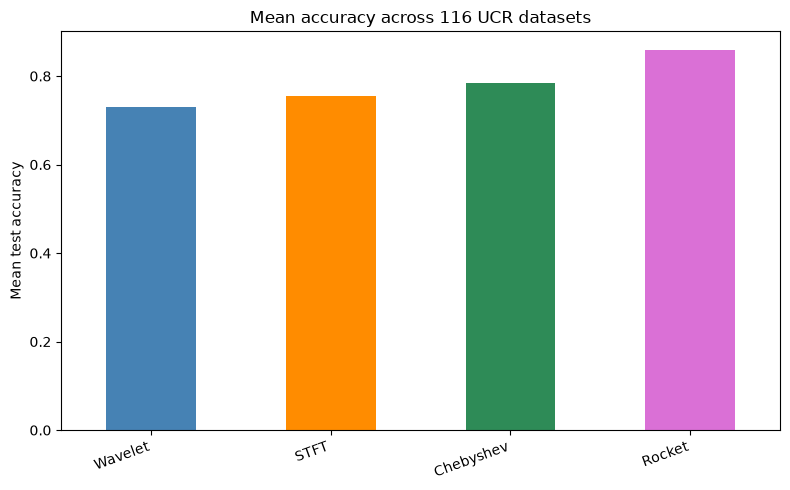

In [9]:
ax = full_results_df.set_index("dataset")[full_rep_cols].mean().plot(
    kind="bar", figsize=(8, 5), color=["steelblue", "darkorange", "seagreen", "orchid", "firebrick"])
ax.set_ylabel("Mean test accuracy")
ax.set_title(f"Mean accuracy across {len(full_results_df)} UCR datasets")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [10]:
space_time_summary = (
    full_results_long_df
    .groupby("representation")[["accuracy", "n_features", "extract_time_s", "classifier_time_s"]]
    .mean()
)
space_time_summary["total_time_s"] = (
    space_time_summary["extract_time_s"].fillna(0) + space_time_summary["classifier_time_s"]
)
space_time_summary = space_time_summary.reindex(list(FULL_REPRESENTATIONS.keys()) + ["Rocket"])
space_time_summary.round(4)


,accuracy,n_features,extract_time_s,classifier_time_s,total_time_s
representation,,,,,
Wavelet,0.7302,565.8276,0.0597,0.5823,0.6420
STFT,0.7545,598.1034,0.2292,0.5884,0.8176
Chebyshev,0.7833,138.1034,0.0236,0.5492,0.5728
Rocket,0.8582,20000.0000,108.5160,0.0000,108.5160


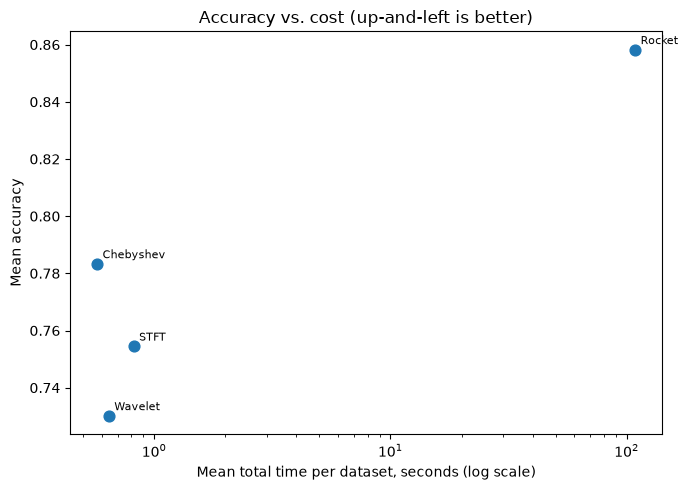

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(space_time_summary["total_time_s"], space_time_summary["accuracy"], s=60)
for rep, r in space_time_summary.iterrows():
    ax.annotate(rep, (r["total_time_s"], r["accuracy"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Mean total time per dataset, seconds (log scale)")
ax.set_ylabel("Mean accuracy")
ax.set_title("Accuracy vs. cost (up-and-left is better)")
plt.tight_layout()
plt.show()


## 7b. Per-dataset view: accuracy gap and feature count

The mean accuracy in the table above can hide how results are distributed. These cells show, **for every dataset**:

- **Top panel:** STCT's accuracy minus the accuracy of the best competing technique on that dataset, in percentage points. Positive (green) means STCT is the best on that dataset; negative (red) means a competitor beats it.
- **Bottom panel:** the number of features each technique uses on that dataset (log scale), so the accuracy gap can be read against its cost.

`INCLUDE_ROCKET_IN_BEST = False` keeps the reference set to the matched random-forest baselines (Wavelet, STFT), as in the paper's main comparison. Set it to `True` to compare against the best of all techniques including Rocket.

## 8. Statistical testing

Paired Wilcoxon signed-rank tests with Bonferroni correction, plus a
Friedman omnibus test across the three baselines, following standard
practice for multi-dataset classifier comparison (Demsar, 2006).


In [14]:
def paired_significance_report(df, cols, label=""):
    valid_idx = df[cols].dropna().index
    arrs = {c: df.loc[valid_idx, c].values for c in cols}
    n = len(valid_idx)
    print(f"--- {label} (n={n} datasets with complete data) ---")
    if n < 3:
        print("Too few complete datasets for testing.")
        return None
    if len(cols) > 2:
        stat, p = stats.friedmanchisquare(*[arrs[c] for c in cols])
        print(f"Friedman omnibus: chi2={stat:.3f}, p={p:.4f}")
    from itertools import combinations
    pairs = list(combinations(cols, 2))
    alpha_corrected = 0.05 / len(pairs)
    rows = []
    for a, b in pairs:
        diffs = arrs[a] - arrs[b]
        if np.allclose(diffs, 0):
            print(f"{a} vs {b}: identical, skipping"); continue
        w, p = stats.wilcoxon(arrs[a], arrs[b])
        d = diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 0.0
        sig = "***" if p < alpha_corrected else ("*" if p < 0.05 else "")
        rows.append({"comparison": f"{a} vs {b}", "mean_diff": diffs.mean(),
                      "wilcoxon_p": p, "cohens_d": d, "bonferroni_sig": p < alpha_corrected})
        print(f"{a:20s} vs {b:20s} | mean_diff={diffs.mean():+.4f} | p={p:.4f} {sig} | d={d:.3f}")
    print(f"(Bonferroni-corrected alpha = {alpha_corrected:.4f} for {len(pairs)} comparisons)")
    return pd.DataFrame(rows)

print("=" * 80)
baseline_stats = paired_significance_report(
    full_results_df, ["Wavelet", "STFT", "Chebyshev"], label="Baselines")



--- Baselines (n=116 datasets with complete data) ---
Friedman omnibus: chi2=29.623, p=0.0000
Wavelet              vs STFT                 | mean_diff=-0.0243 | p=0.0032 *** | d=-0.222
Wavelet              vs Chebyshev            | mean_diff=-0.0531 | p=0.0000 *** | d=-0.660
STFT                 vs Chebyshev            | mean_diff=-0.0288 | p=0.0012 *** | d=-0.302
(Bonferroni-corrected alpha = 0.0167 for 3 comparisons)


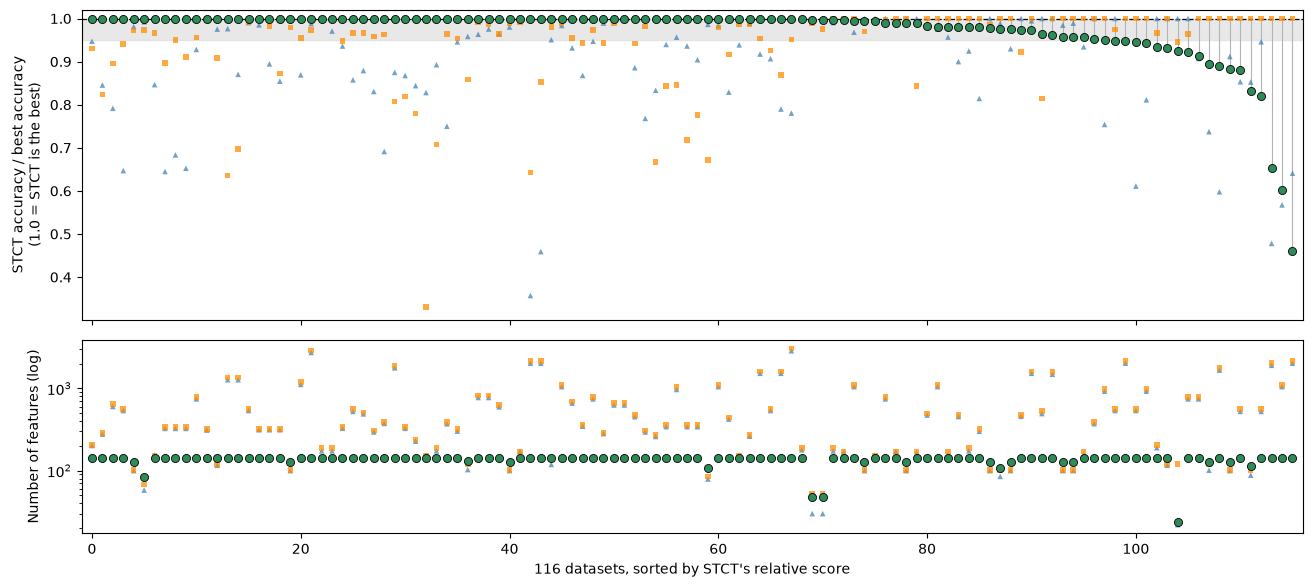

Caption numbers:
  Best technique per dataset: STCT 60, STFT 31, Wavelet 25.
  STCT is the best technique on 68/116 datasets and within 5% of the best on 98/116 (median relative score 1.000).
  Where another technique is best, it uses a median of 1.7x more features than STCT.


In [19]:
# ---- STCT relative to the best technique on each dataset (classification) ----
STCT = "Chebyshev"
METHODS = ["Wavelet", "STFT", "Chebyshev"]    # drop "Rocket" to use only the matched baselines
score = full_results_df.set_index("dataset")[METHODS].dropna()
feats = (full_results_long_df.pivot_table(index="dataset", columns="representation", values="n_features")
         .reindex(score.index))
best_name = score.idxmax(axis=1)                       # best technique on each dataset (may be STCT itself)
rel_all = score.div(score.max(axis=1), axis=0)         # every technique / best; 1.0 = it matches the best
YLABEL = "STCT accuracy / best accuracy\n(1.0 = STCT is the best)"
TITLE = f"STCT relative to the best technique on each of {len(score)} UCR datasets"
FNAME = "relative_classification"

# ---- shared plotting body ----
NAMES = {"Chebyshev": "STCT"}
disp = lambda s: NAMES.get(s, s)
COLORS  = {"STCT": "seagreen", "Wavelet": "steelblue", "STFT": "darkorange", "Rocket": "firebrick"}
MARKERS = {"STCT": "o", "Wavelet": "^", "STFT": "s", "Rocket": "D"}

rel = rel_all[STCT]
best_disp = best_name.map(disp)
order = rel.sort_values(ascending=False).index          # datasets sorted by STCT's relative score
n = len(order); x = np.arange(n)
others = [m for m in METHODS if m != STCT]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(7.5, 0.11 * n + 3), 6.8), sharex=True,
                               gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.08})

# top: every technique relative to the best on that dataset; STCT emphasised
ax1.axhspan(0.95, 1.0, color="0.85", alpha=0.6, zorder=0)
ax1.axhline(1.0, color="k", ls="--", lw=0.9, zorder=1)
ax1.vlines(x, rel.loc[order].values, 1.0, color="0.7", lw=0.8, zorder=1)      # STCT's gap to the best
for m in others:
    ax1.scatter(x, rel_all.loc[order, m].values, marker=MARKERS[disp(m)], s=16, alpha=0.75,
                color=COLORS[disp(m)], edgecolor="none", zorder=2)
ax1.scatter(x, rel.loc[order].values, marker="o", s=34, color=COLORS["STCT"],
            edgecolor="k", linewidth=0.6, zorder=4)
ax1.set_ylim(max(0, rel_all.loc[order].min().min() - 0.03), 1.02)
ax1.set_ylabel(YLABEL)

# bottom: number of features of every technique; STCT emphasised
for m in others:
    ax2.scatter(x, feats.loc[order, m].values, marker=MARKERS[disp(m)], s=16, alpha=0.75,
                color=COLORS[disp(m)], edgecolor="none", zorder=2)
ax2.scatter(x, feats.loc[order, STCT].values, marker="o", s=34, color=COLORS["STCT"],
            edgecolor="k", linewidth=0.6, zorder=4)
ax2.set_yscale("log")
ax2.set_ylabel("Number of features (log)")
ax2.set_xlim(-1, n)
ax2.set_xlabel(f"{n} datasets, sorted by STCT's relative score")
if n <= 30:
    ax2.set_xticks(x); ax2.set_xticklabels(order, rotation=90, fontsize=7)

plt.savefig(FNAME + ".png", dpi=300, bbox_inches="tight")
plt.savefig(FNAME + ".pdf", bbox_inches="tight")
plt.show()

# numbers for the caption
n_best = int((rel >= 1 - 1e-12).sum()); n95 = int((rel >= 0.95).sum())
f_best = pd.Series([feats.loc[ds, best_name.loc[ds]] for ds in rel.index], index=rel.index)
mask = (best_name != STCT).values
ratio = (f_best / feats[STCT]).values[mask]
print("Caption numbers:")
print("  Best technique per dataset: " + ", ".join(f"{k} {v}" for k, v in best_disp.value_counts().items()) + ".")
print(f"  STCT is the best technique on {n_best}/{n} datasets and within 5% of the best on {n95}/{n} "
      f"(median relative score {rel.median():.3f}).")
if len(ratio):
    print(f"  Where another technique is best, it uses a median of {np.median(ratio):.1f}x more features than STCT.")

In [20]:
full_results_df.to_csv('results_classification.csv')

## 9. Conclusion

Read the printed statistics above directly:

- **Wavelet vs. STFT vs. Chebyshev** tells you whether windowed Chebyshev is
  a genuinely competitive representation on the full archive (it was, on the
  28-dataset run: matched STFT, beat wavelet decisively).
- **Chebyshev vs. Chebyshev-ROCKET vs. Rocket** tells you whether borrowing
  Rocket's own pooling architecture with Chebyshev-shaped kernels narrows the
  gap, and by how much, at what fraction of Rocket's feature count and
  runtime (Section 7's accuracy-vs-cost plot makes this concrete).

`N_CHEBY_ROCKET_KERNELS = 200` here is far below Rocket's typical ~10,000 --
any remaining gap should not be read as "Chebyshev-shaped kernels are worse
than random ones," only that 200 of them isn't enough. Scaling kernel count
toward parity with Rocket is the natural next experiment.
